In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from src.analysis.calculate_metastability_optimize_K import (find_optimal_K,
                                                             plot_K_optimization,
                                                             plot_arr_K_optimization
)

%load_ext autoreload
%autoreload 2 

In [2]:
# Newly constructed connectivity matrix from distance matrix 
# name_data = "distance_matrix_50"
# name_data = "00_connectomes_orig" # 
name_data = "01_consensus_bin_density_10_percent_50"


################################### EITHER: ###################################

if name_data.startswith("distance_matrix"):
    # Load distance matrices and convert to connectomes
    distance_matrix_path = f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/02_distance_matrices/{name_data}.npy"
    distance_matrices = np.load(distance_matrix_path)

    connectomes = []
    for d in distance_matrices:
        A = np.exp(-d / d.max())
        np.fill_diagonal(A, 0)  # No self-connections
        A = (A + A.T) / 2  # Make symmetric
        A = (A - A.min()) / (A.max() - A.min())
        np.fill_diagonal(A, 0)  # No self-connections
        connectomes.append(A)

    connectomes = np.array(connectomes)
    name_data = name_data + "_not_thresholded"


################################### OR: ###################################


if name_data.startswith("01_consensus") or name_data.startswith("00_connectomes"):
    # Load preprocessed connectomes
    data_path = f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/01_connectomes/{name_data}.npy"
    connectomes = np.load(data_path)


In [5]:
save_path = Path(f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/testing/metastability_optimize_K/emp/") # {name_data}_finer_window")
save_path.mkdir(parents=True, exist_ok=True)


ids_to_evaluate = range(225) #  [0, 103, 169, 188, 206]
K_range = np.logspace(2, 4, 41) # -4, 3, 41)
optimal_metric = 'global'

# Calculating optimal Ks

In [6]:
from src.analysis.dynamic_measures import spectral_radius

Optimizing K: 100%|██████████| 41/41 [01:50<00:00,  2.70s/it]


Optimization Results:
Metric optimized: global
Optimal K: 750.0000
Value at optimal K: 0.1099
K range tested: [0.0000, 3000.0000]
Number of K values: 41



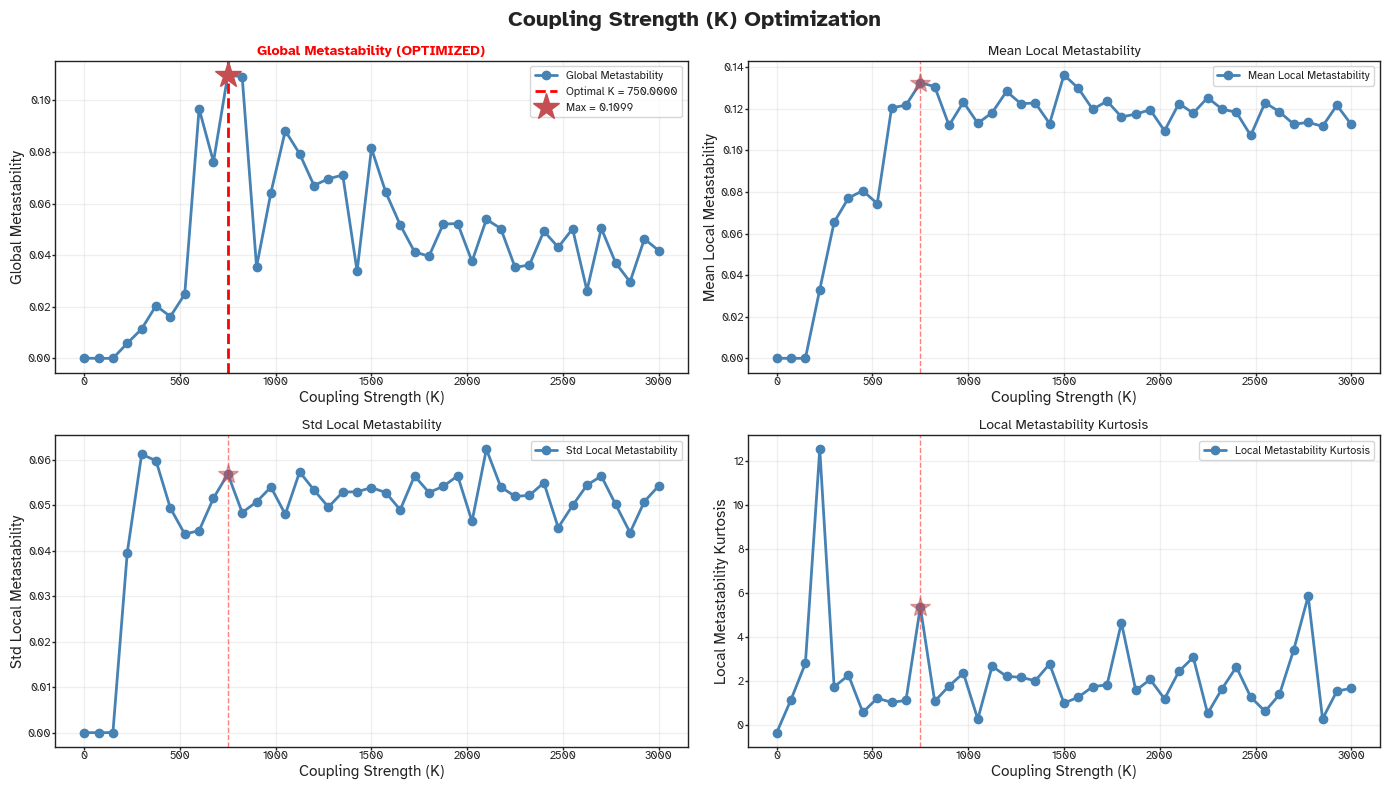

Optimizing K: 100%|██████████| 41/41 [01:52<00:00,  2.73s/it]


Optimization Results:
Metric optimized: global
Optimal K: 1050.0000
Value at optimal K: 0.1082
K range tested: [0.0000, 3000.0000]
Number of K values: 41



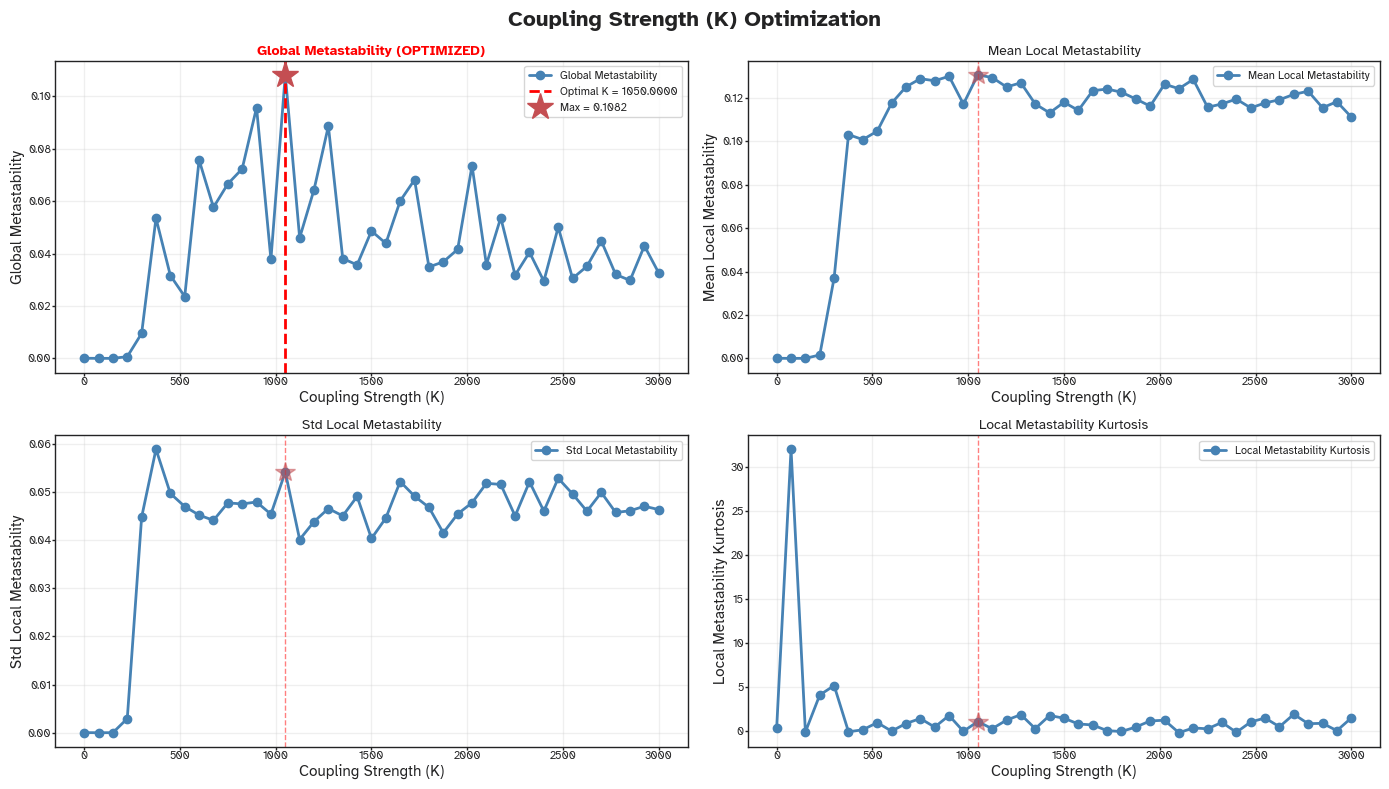

Optimizing K: 100%|██████████| 41/41 [01:52<00:00,  2.75s/it]


Optimization Results:
Metric optimized: global
Optimal K: 675.0000
Value at optimal K: 0.1084
K range tested: [0.0000, 3000.0000]
Number of K values: 41



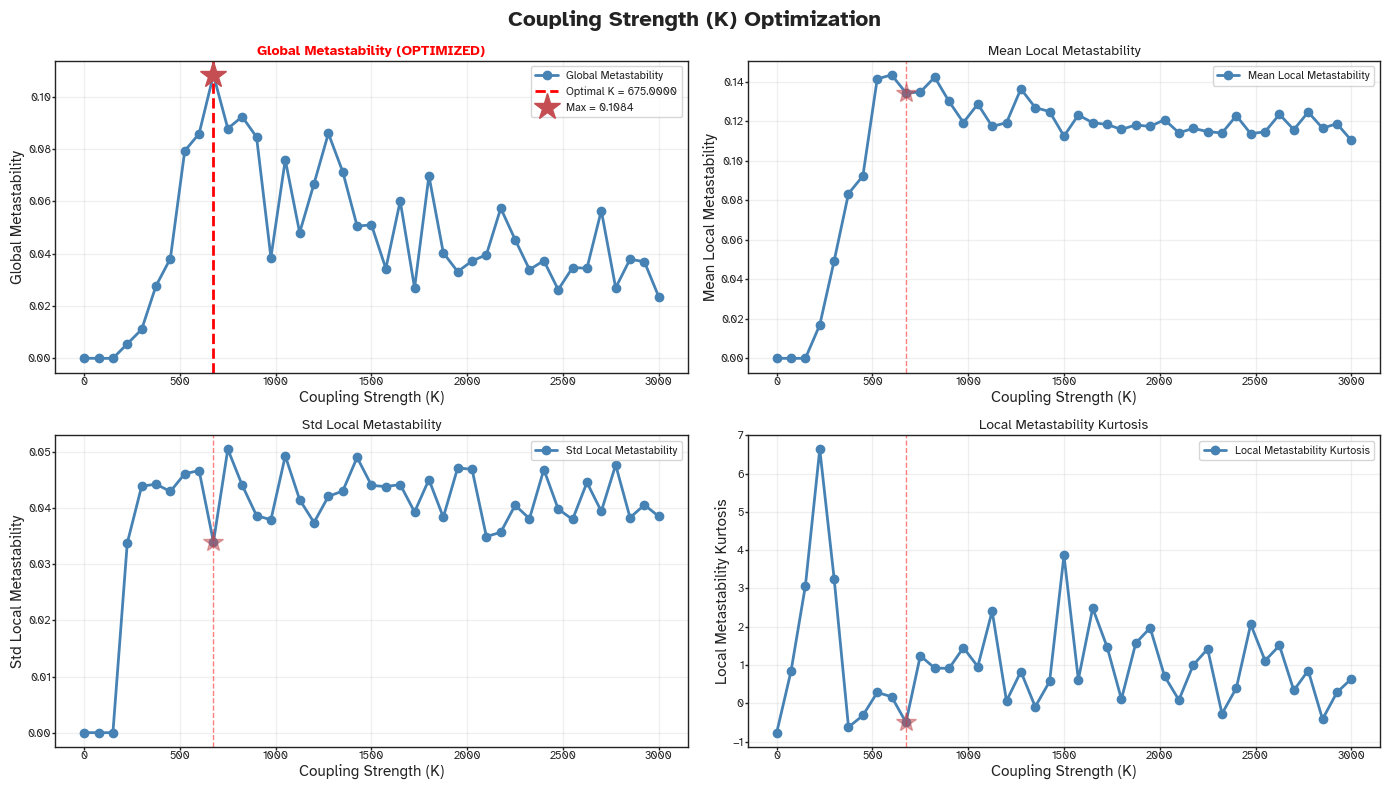

Optimizing K: 100%|██████████| 41/41 [01:52<00:00,  2.75s/it]



Optimization Results:
Metric optimized: global
Optimal K: 675.0000
Value at optimal K: 0.1163
K range tested: [0.0000, 3000.0000]
Number of K values: 41



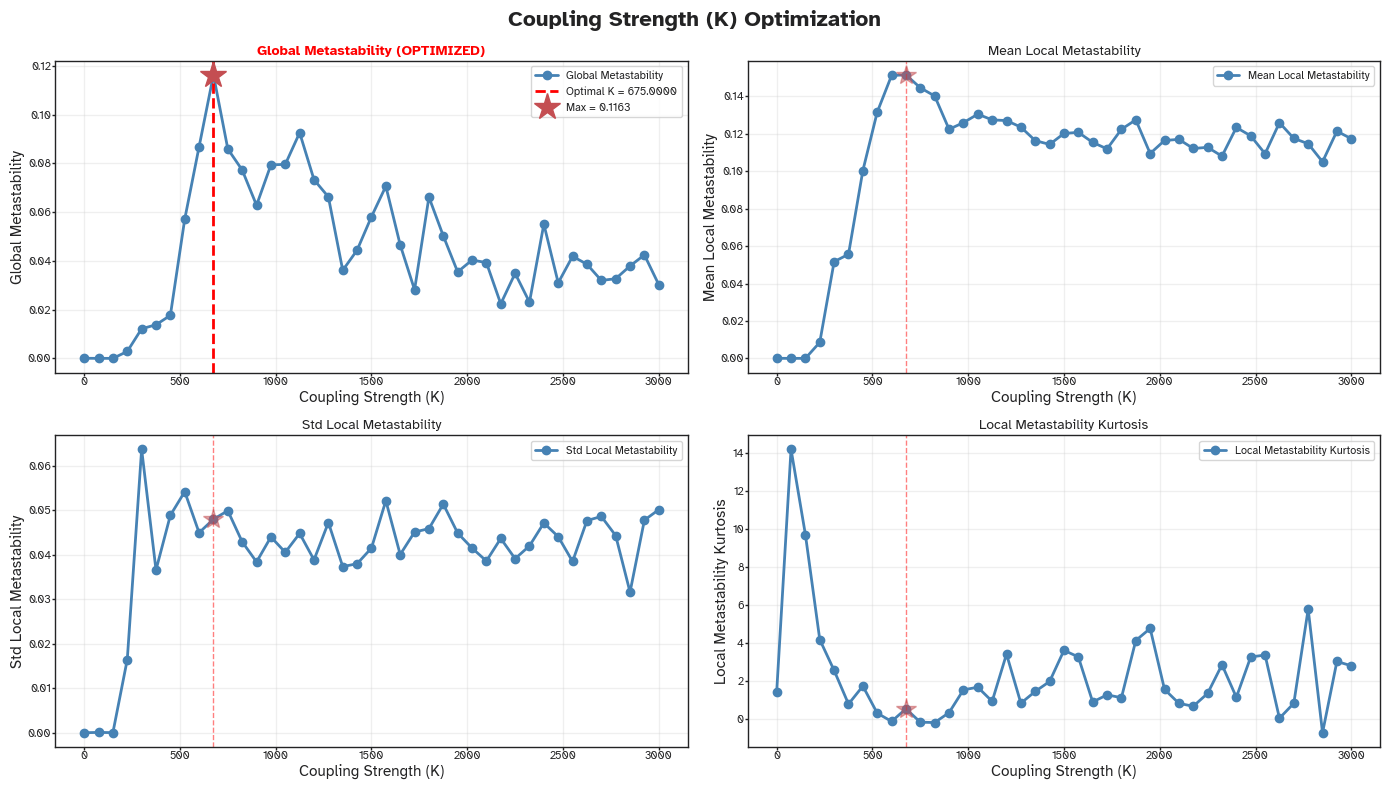

Optimizing K: 100%|██████████| 41/41 [01:53<00:00,  2.76s/it]


Optimization Results:
Metric optimized: global
Optimal K: 525.0000
Value at optimal K: 0.0858
K range tested: [0.0000, 3000.0000]
Number of K values: 41



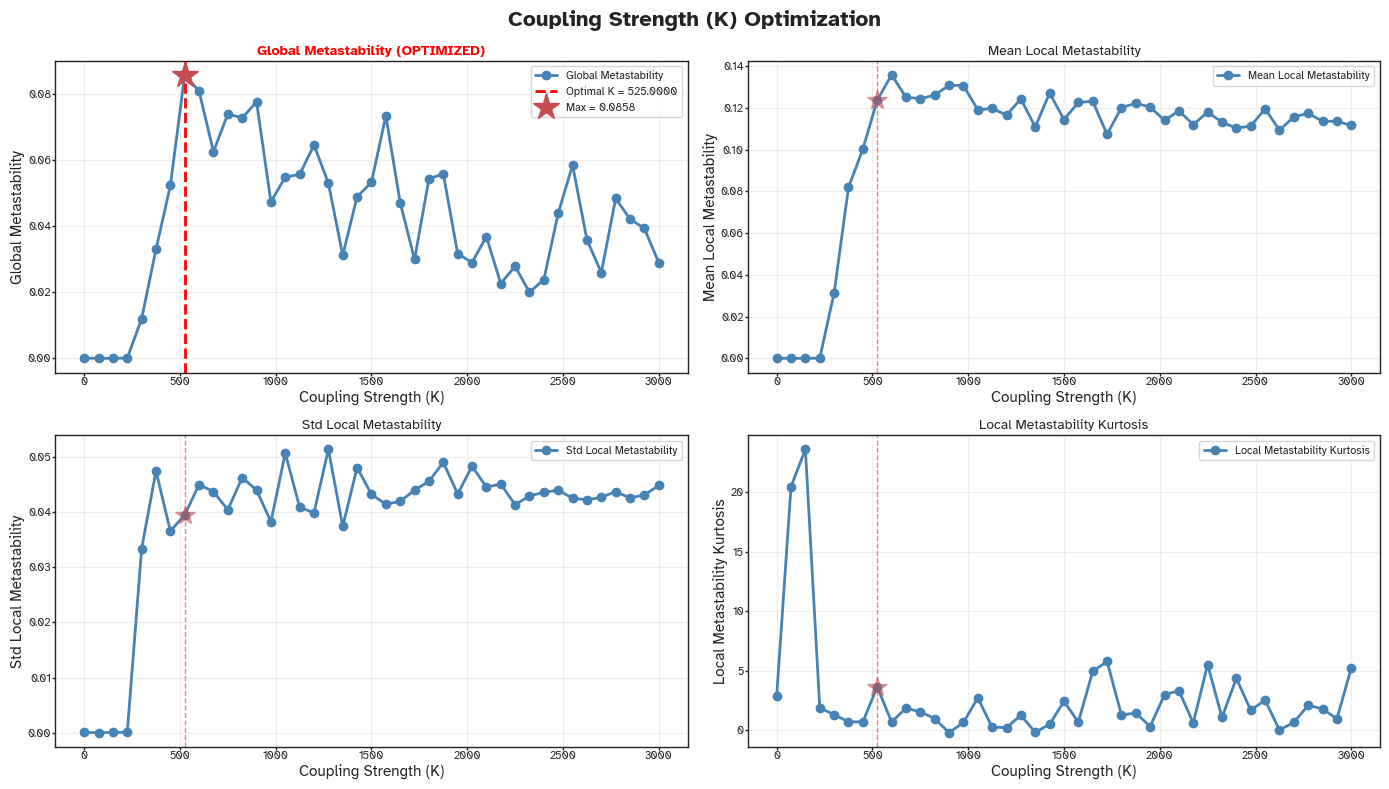

Optimizing K: 100%|██████████| 41/41 [01:52<00:00,  2.75s/it]


Optimization Results:
Metric optimized: global
Optimal K: 750.0000
Value at optimal K: 0.1291
K range tested: [0.0000, 3000.0000]
Number of K values: 41



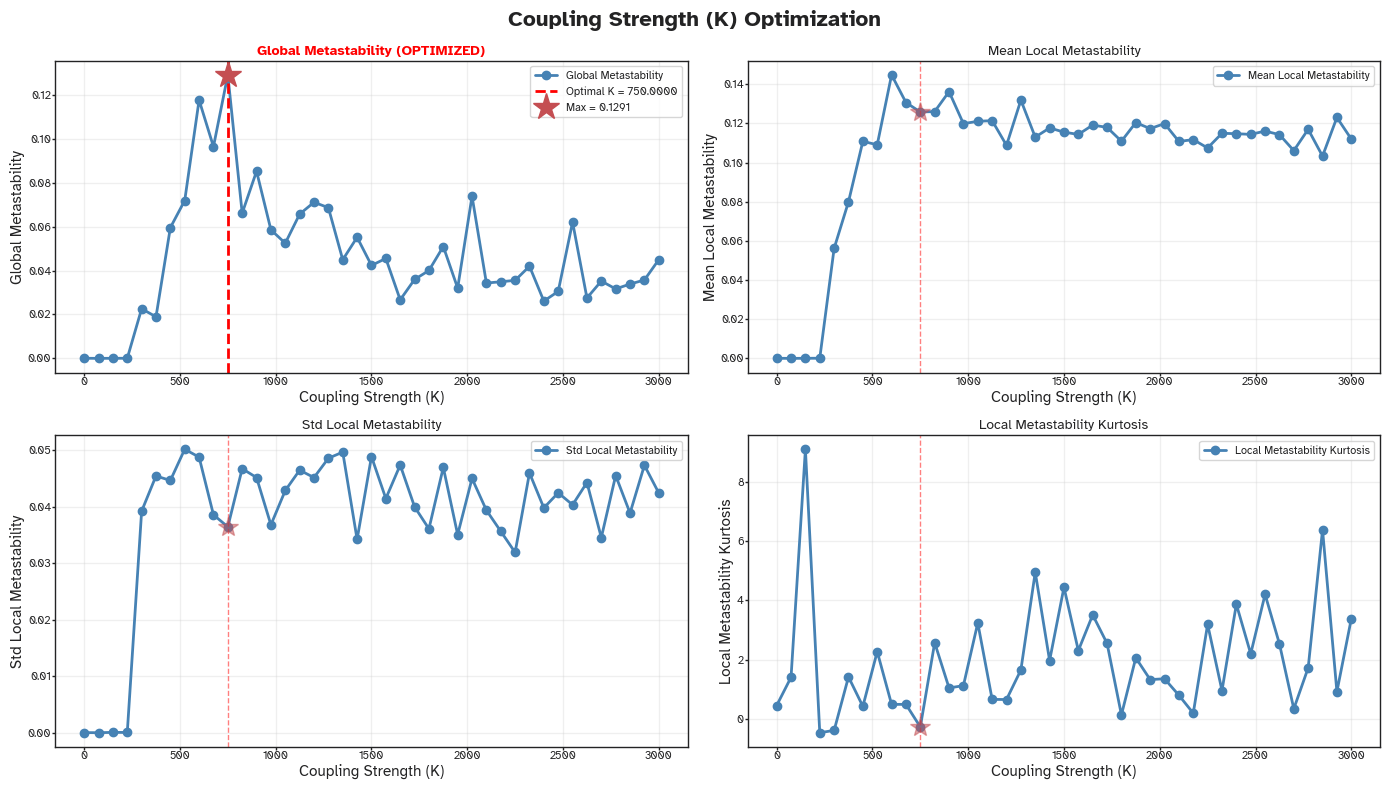

Optimizing K: 100%|██████████| 41/41 [01:52<00:00,  2.73s/it]


Optimization Results:
Metric optimized: global
Optimal K: 600.0000
Value at optimal K: 0.1111
K range tested: [0.0000, 3000.0000]
Number of K values: 41



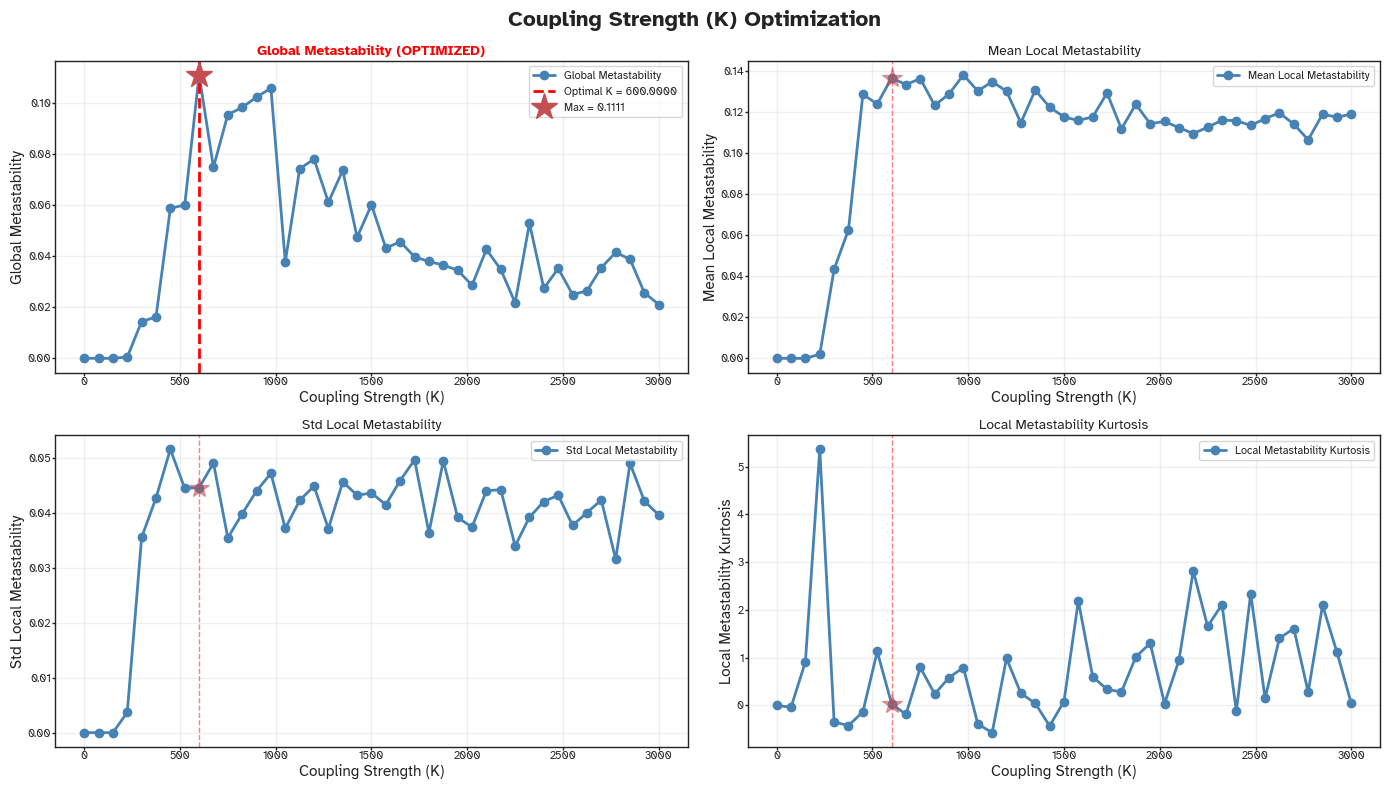

Optimizing K: 100%|██████████| 41/41 [01:51<00:00,  2.72s/it]


Optimization Results:
Metric optimized: global
Optimal K: 600.0000
Value at optimal K: 0.1282
K range tested: [0.0000, 3000.0000]
Number of K values: 41



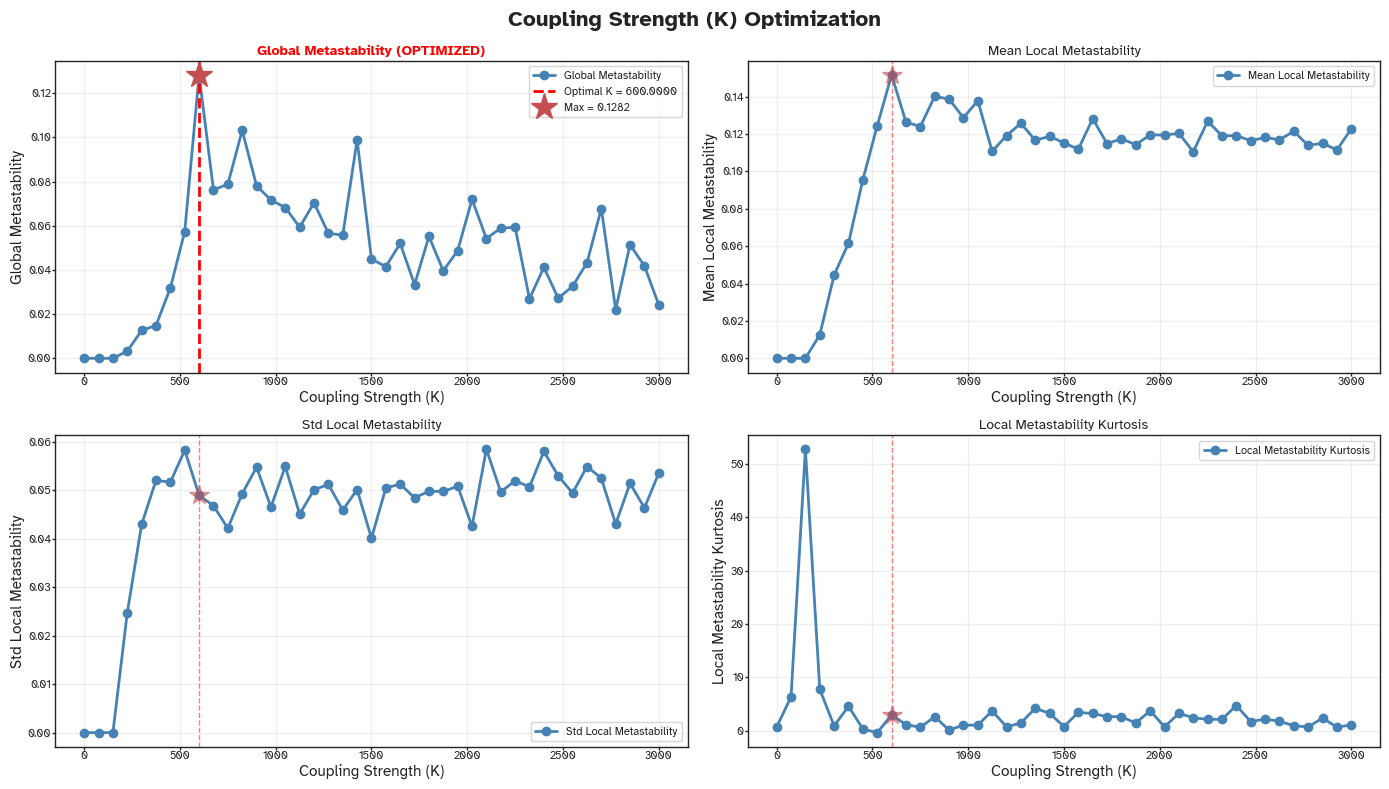

Optimizing K: 100%|██████████| 41/41 [01:51<00:00,  2.72s/it]


Optimization Results:
Metric optimized: global
Optimal K: 675.0000
Value at optimal K: 0.1190
K range tested: [0.0000, 3000.0000]
Number of K values: 41



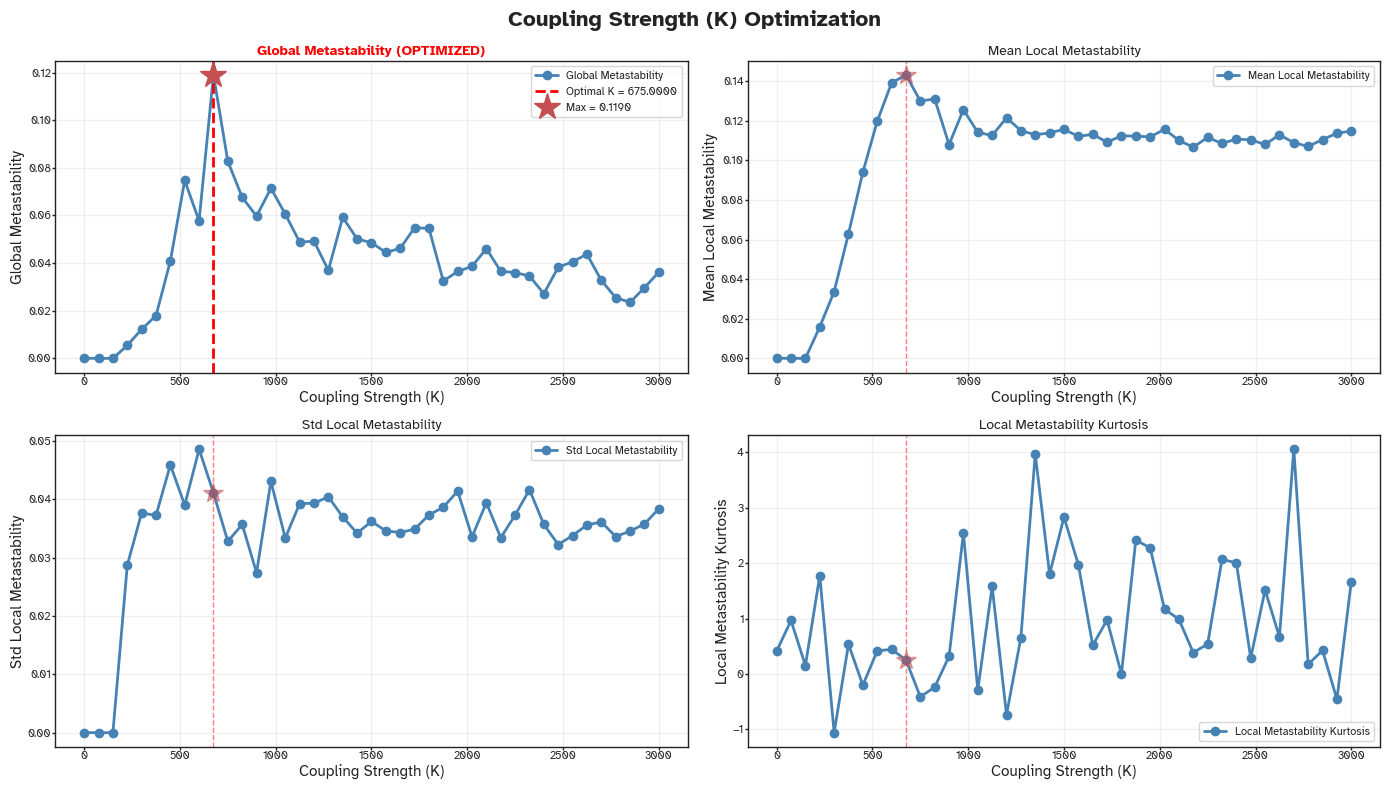

Optimizing K: 100%|██████████| 41/41 [01:54<00:00,  2.78s/it]


Optimization Results:
Metric optimized: global
Optimal K: 825.0000
Value at optimal K: 0.1118
K range tested: [0.0000, 3000.0000]
Number of K values: 41



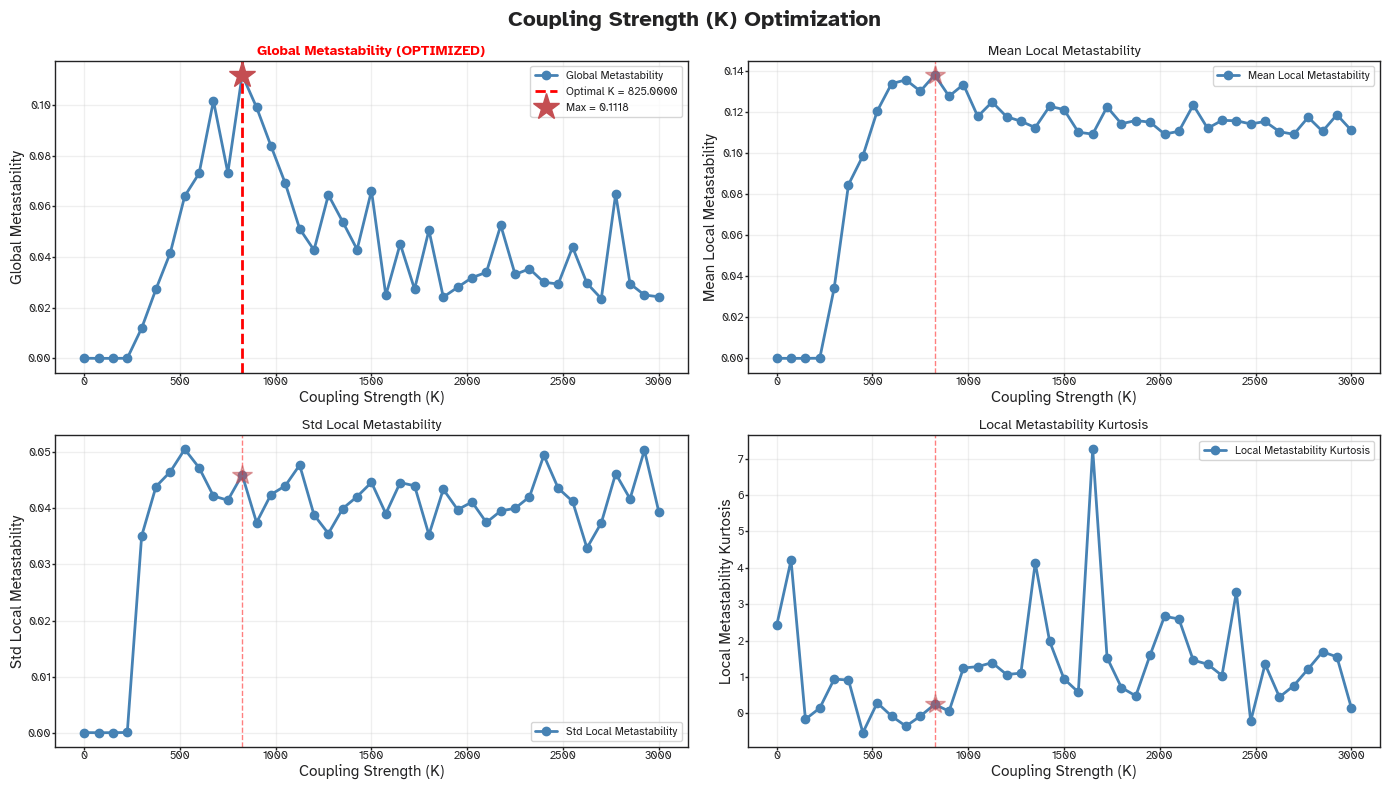

Optimizing K: 100%|██████████| 41/41 [01:54<00:00,  2.79s/it]


Optimization Results:
Metric optimized: global
Optimal K: 750.0000
Value at optimal K: 0.1138
K range tested: [0.0000, 3000.0000]
Number of K values: 41



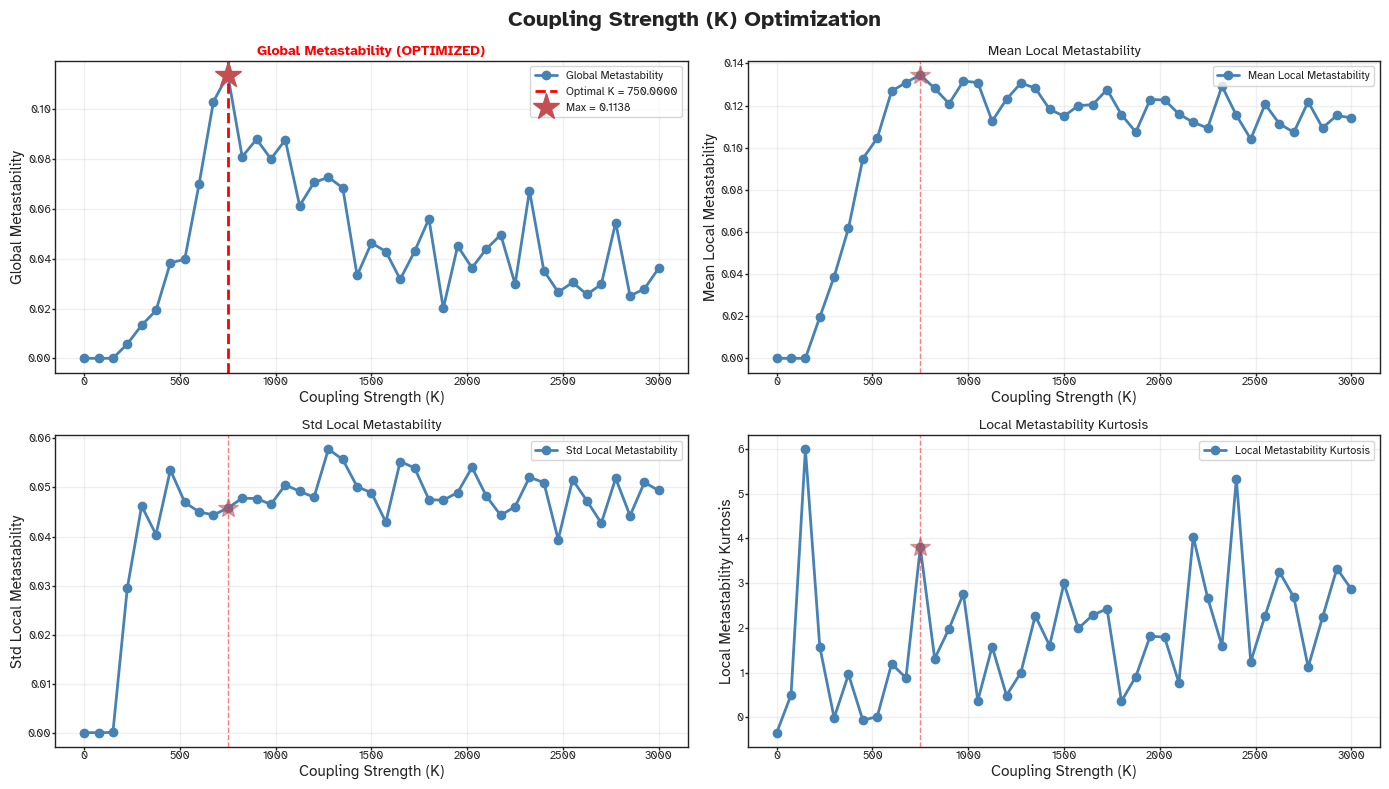

Optimizing K:  54%|█████▎    | 22/41 [00:59<00:55,  2.94s/it]

In [ ]:
# bin and thres and sampled to 100 nodes total: 

ids_to_evaluate = range(225) # [0, 103, 169, 188, 206]
K_range = np.linspace(0, 3000, 41) # np.logspace(-4, 3, 41)
optimal_metric = 'global'


# # First get optimal K for each animal, if this is already saved, load it
# if (save_path / "K_optimal_arr.npy").exists():
#     optimal_K_arr = np.load(save_path / "K_optimal_arr_partial.npy").tolist()
#     results_arr = np.load(save_path / "results_arr_partial.npy", allow_pickle=True).tolist()
#     start_idx_arr = np.load(save_path / "evaluated_ids_partial.npy").tolist()
# else:
start_idx = 0
optimal_K_arr = [] 
results_arr = [] 
start_idx_arr = []

ids_to_evaluate = set(ids_to_evaluate) - set(start_idx_arr)
ids_to_evaluate = list(ids_to_evaluate)


for animal_id in ids_to_evaluate: 
    A = connectomes[animal_id]
    A = A / spectral_radius(A)  # Normalize by spectral radius
    
    # Find optimal K
    optimal_K, results = find_optimal_K(
        A, 
        K_range=K_range,
        metric=optimal_metric, 
        sim_time=500,  # Shorter for example
        verbose=True
    )

    # Plot results
    plot_K_optimization(results)
    plt.show()
    
    results = {"optimal_K": optimal_K, 
                "results": results}

    results_arr.append(results)
    optimal_K_arr.append(optimal_K)
    start_idx_arr.append(animal_id)

    # save intermediate results
    np.save(save_path / f"results_arr_emp_partial_animal_id_{animal_id}.npy", results_arr)
    np.save(save_path / f"K_optimal_arr_emp_partial_animal_id_{animal_id}.npy", optimal_K_arr)
    np.save(save_path / f"evaluated_ids_emp_partial_animal_id_{animal_id}.npy", start_idx_arr)

    # break # 2:17  -> 1:03

print(save_path)
# total: 54 min for 5 animals (when 200 total nodes)

In [ ]:
for id in ids_to_evaluate: 
    results_arr = np.load(save_path / f"results_arr_partial_animal_id_{id}.npy", allow_pickle=True)
    start_idx_arr = np.load(save_path / f"evaluated_ids_partial_animal_id_{id}.npy", allow_pickle=True)

In [ ]:
for res in results_arr: 
    print(res["results"].keys()) # ["optimal_K"])
    print(res.keys())

dict_keys(['K_values', 'global', 'local_mean', 'local_std', 'local_kurtosis', 'DFA', 'optimal_K', 'optimal_metric', 'optimal_value'])
dict_keys(['optimal_K', 'results'])
dict_keys(['K_values', 'global', 'local_mean', 'local_std', 'local_kurtosis', 'DFA', 'optimal_K', 'optimal_metric', 'optimal_value'])
dict_keys(['optimal_K', 'results'])
dict_keys(['K_values', 'global', 'local_mean', 'local_std', 'local_kurtosis', 'DFA', 'optimal_K', 'optimal_metric', 'optimal_value'])
dict_keys(['optimal_K', 'results'])
dict_keys(['K_values', 'global', 'local_mean', 'local_std', 'local_kurtosis', 'DFA', 'optimal_K', 'optimal_metric', 'optimal_value'])
dict_keys(['optimal_K', 'results'])
dict_keys(['K_values', 'global', 'local_mean', 'local_std', 'local_kurtosis', 'DFA', 'optimal_K', 'optimal_metric', 'optimal_value'])
dict_keys(['optimal_K', 'results'])


Figure saved to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/testing/metastability_optimize_K/01_consensus_bin_density_10_percent_50_finer_window/K_optimization_plots_empirical_01_consensus_bin_density_10_percent_50.pdf


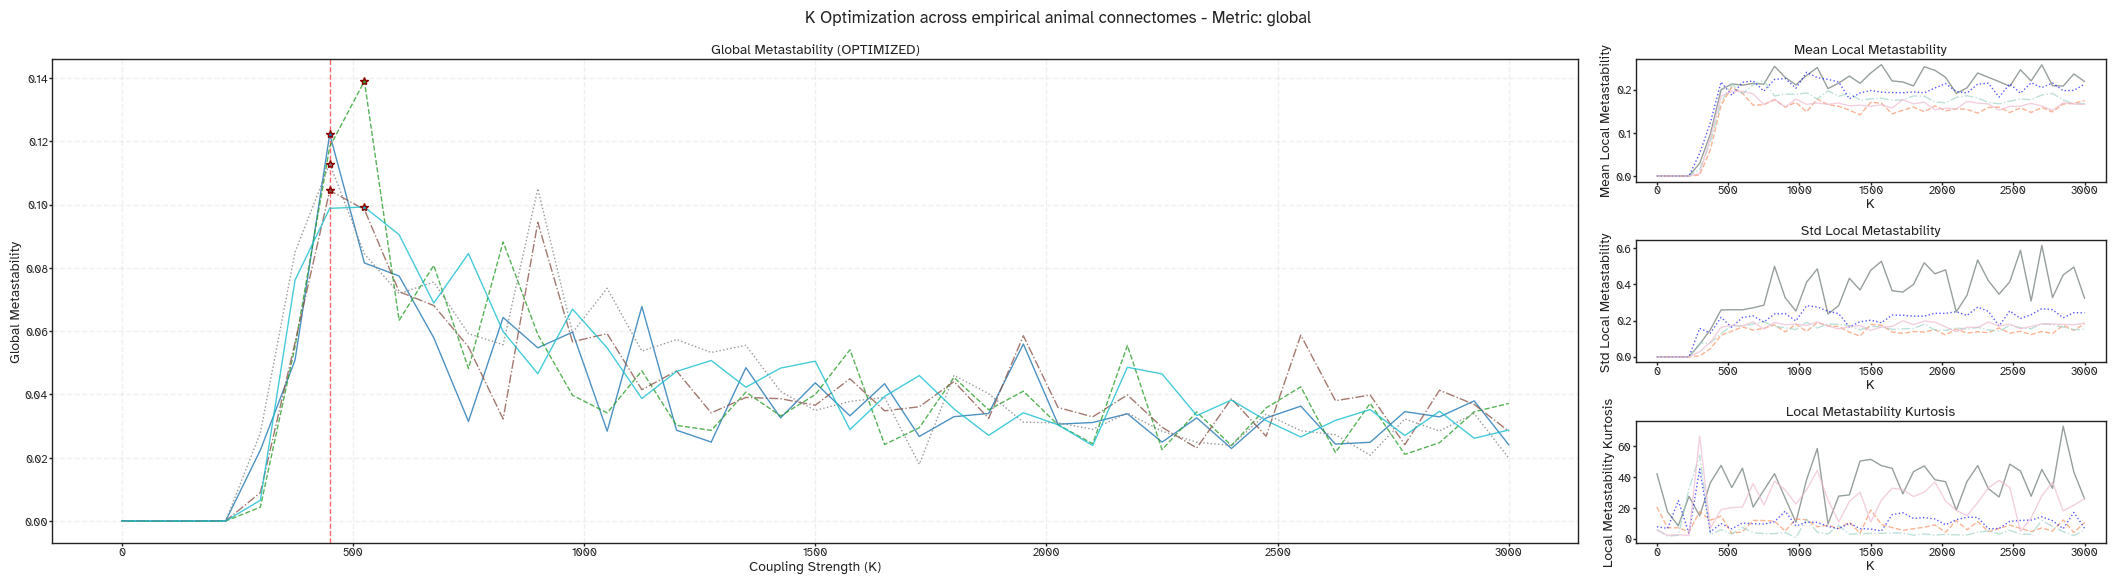

In [ ]:
# plot_K_optimization(results)

plot_arr_K_optimization( # attention: Only seems to plot the global metric?? 
    results_arr,
    start_idx_arr,
    optimal_metric, 
    title=f"K Optimization across empirical animal connectomes - Metric: {optimal_metric}",
    save_path=save_path / f"K_optimization_plots_empirical_{name_data}.pdf")

# Generated connectomes

In [ ]:
# from notebook_setup import setup
from vizman import viz
import numpy as np
from pathlib import Path

from matplotlib import font_manager
for font in font_manager.findSystemFonts("figures/Atkinson_Typeface/"):
    font_manager.fontManager.addfont(font)

viz.set_visual_style()
default_sizes = viz.load_data_from_json("sizes.json")
default_colors = viz.load_data_from_json("colors.json")
default_cmaps = viz.give_colormaps()

# from kaysons_visual_config import * # Kayson's file. 
from pypalettes import load_cmap
cmap = load_cmap("Aurora")

from src.visualization.find_and_plot_closest_connectome import find_closest_connectome


In [ ]:
subject_id = 206
experiment_name = "76_90000_samples_animal_206" 
base_path = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset") / experiment_name

data_dir = base_path / "generated_networks"
save_dir = base_path / "metastability_optimize_K_gen" # generated_networks_visualizations"
save_dir.mkdir(parents=True, exist_ok=True)

margin_x = 0.5
margin_y = 0.05
interesting_eta_and_gamma_combinations = [
    [-8+margin_x, 1-margin_y],  
    [3-margin_x, 1-margin_y], 
    [-0.8, 0.18],
    [3-margin_x, -0.1+margin_y], 
    [-8+margin_x, -0.1+margin_y],
    [-5, 0.5],
]

# Choose clustering method: 'spectral', 'hierarchical', 'modularity', 'degree', or None
clustering_method = 'spectral'

In [ ]:
number_connectomes = 10 

connectomes_arr = []
eta_arr = []
gamma_arr = []

for i, parameter_combination in enumerate(interesting_eta_and_gamma_combinations):
    target_eta = parameter_combination[0]
    target_gamma = parameter_combination[1]
    
    found_eta, found_gamma, connectome = find_closest_connectome(target_eta, target_gamma, data_dir, number_connectomes=number_connectomes)

    connectomes_arr.append(connectome)
    eta_arr.append(found_eta)
    gamma_arr.append(found_gamma)

connectomes_arr = np.concatenate(connectomes_arr)
print(connectomes_arr.shape)

In [ ]:
for id in range(len(connectomes_arr)):
    A = connectomes_arr[id]
    A = A / spectral_radius(A)  # Normalize by spectral radius

    # Find optimal K
    optimal_K, results = find_optimal_K(
        A, 
        K_range=K_range,
        metric=optimal_metric, 
        sim_time=500, # can be made longer
        verbose=True
    )

    # Plot results
    plot_K_optimization(results)
    
    results = {"optimal_K": optimal_K, 
                "results": results}

    results_arr.append(results)
    optimal_K_arr.append(optimal_K)
    start_idx_arr.append(id)

    # save intermediate results
    np.save(save_dir / f"results_arr_gen_partial_animal_id_{id}.npy", results_arr)
    np.save(save_dir / f"K_optimal_arr_gen_partial_animal_id_{id}.npy", optimal_K_arr)
    np.save(save_dir / f"evaluated_ids_gen_partial_animal_id_{id}.npy", start_idx_arr)

    # break # 2:17  -> 1:03

In [ ]:
print(save_dir)
for id in range(len(connectomes_arr)): 
    results_arr = np.load(save_dir / f"results_arr_partial_animal_id_{id}.npy", allow_pickle=True)
    start_idx_arr = np.load(save_dir / f"evaluated_ids_partial_animal_id_{id}.npy", allow_pickle=True)

plot_arr_K_optimization(
    results_arr,
    start_idx_arr,
    optimal_metric, 
    title=f"K Optimization across generated connectomes - Metric: {optimal_metric}",
    save_path=save_dir / f"K_optimization_plots_generated_{name_data}.pdf")


In [ ]:
# for i, label in enumerate(["A", "B", "C", "D", "E", "F"]):
#     for id in range(len(connectomes_arr)): 
#         results_arr = np.load(save_path / f"results_arr_partial_animal_id_{id}.npy", allow_pickle=True)
#         start_idx_arr = np.load(save_path / f"evaluated_ids_partial_animal_id_{id}.npy", allow_pickle=True)
#         break 

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/testing/metastability_optimize_K/generated_networks_30_01_consensus_bin_density_10_percent_50_finer_window
Figure saved to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/testing/metastability_optimize_K/generated_networks_30_01_consensus_bin_density_10_percent_50_finer_window/K_optimization_plots_01_consensus_bin_density_10_percent_50.pdf


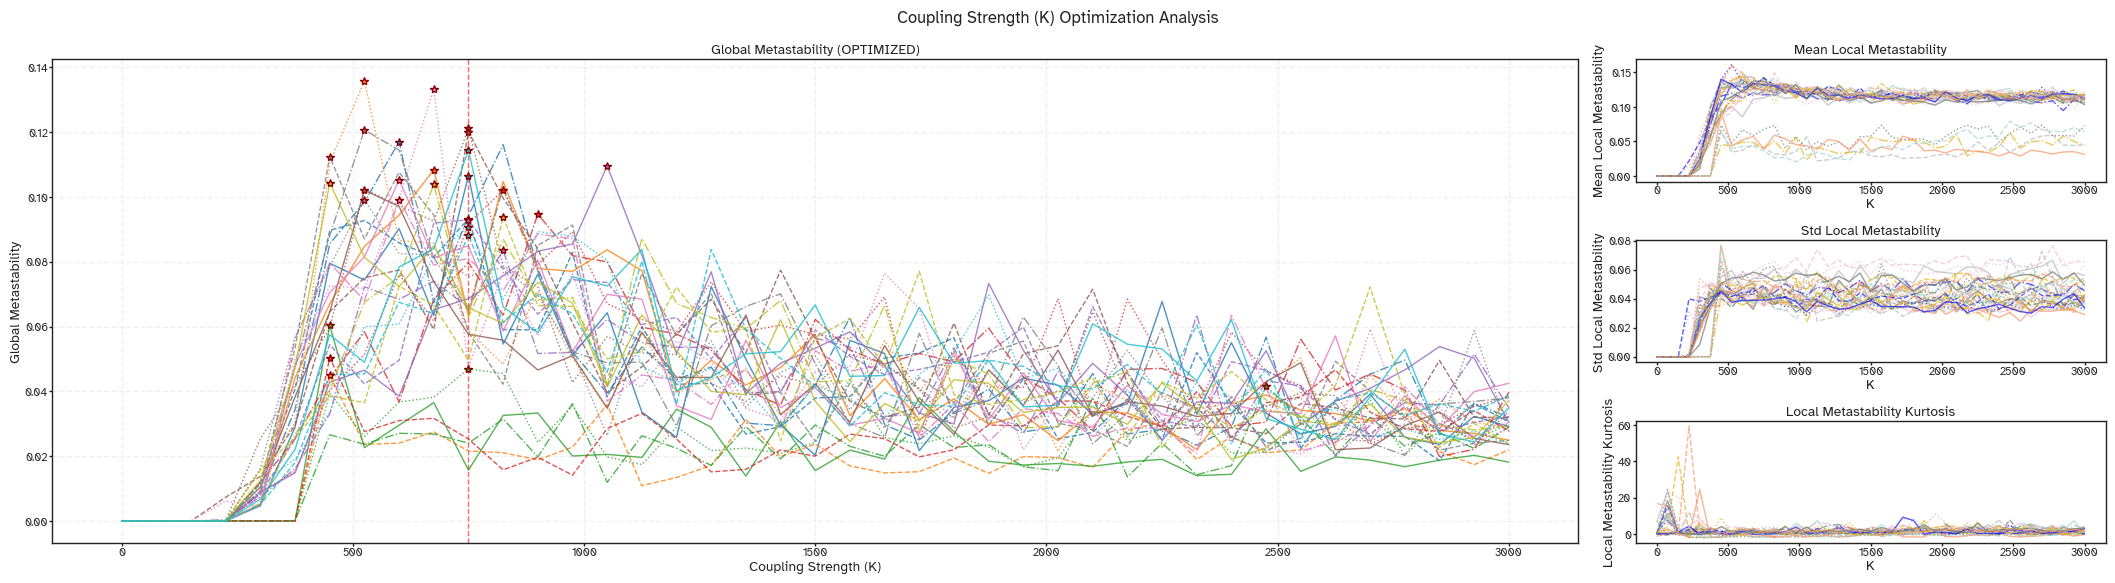

In [ ]:
# GET THE LAST FILE WHERE ALL RESULTS ARE SAVED IN 
print(save_dir)
for id in range(number_connectomes*6): # ids_to_evaluate:
    results_arr = np.load(save_dir / f"results_arr_partial_animal_id_{id}.npy", allow_pickle=True)
    start_idx_arr = np.load(save_dir / f"evaluated_ids_partial_animal_id_{id}.npy", allow_pickle=True)

plot_arr_K_optimization( # attention: Only seems to plot the global metric?? 
    results_arr,
    start_idx_arr,
    optimal_metric, 
    save_path=save_dir / f"K_optimization_plots_{name_data}.pdf")

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/testing/metastability_optimize_K/generated_networks_30_01_consensus_bin_density_10_percent_50_finer_window
Figure saved to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/testing/metastability_optimize_K/generated_networks_30_01_consensus_bin_density_10_percent_50_finer_window/K_optimization_plots_01_consensus_bin_density_10_percent_50_A.pdf
Figure saved to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/testing/metastability_optimize_K/generated_networks_30_01_consensus_bin_density_10_percent_50_finer_window/K_optimization_plots_01_consensus_bin_density_10_percent_50_B.pdf
Figure saved to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/testing/metastability_optimize_K/generated_networks_30_01_consensus_bin_density_10_percent_50_finer_window/K_optimization_plots_01_consensus_bin_density_10_percent_50_C.pdf
Figure saved to: /Users/adrian/Documents/01_project

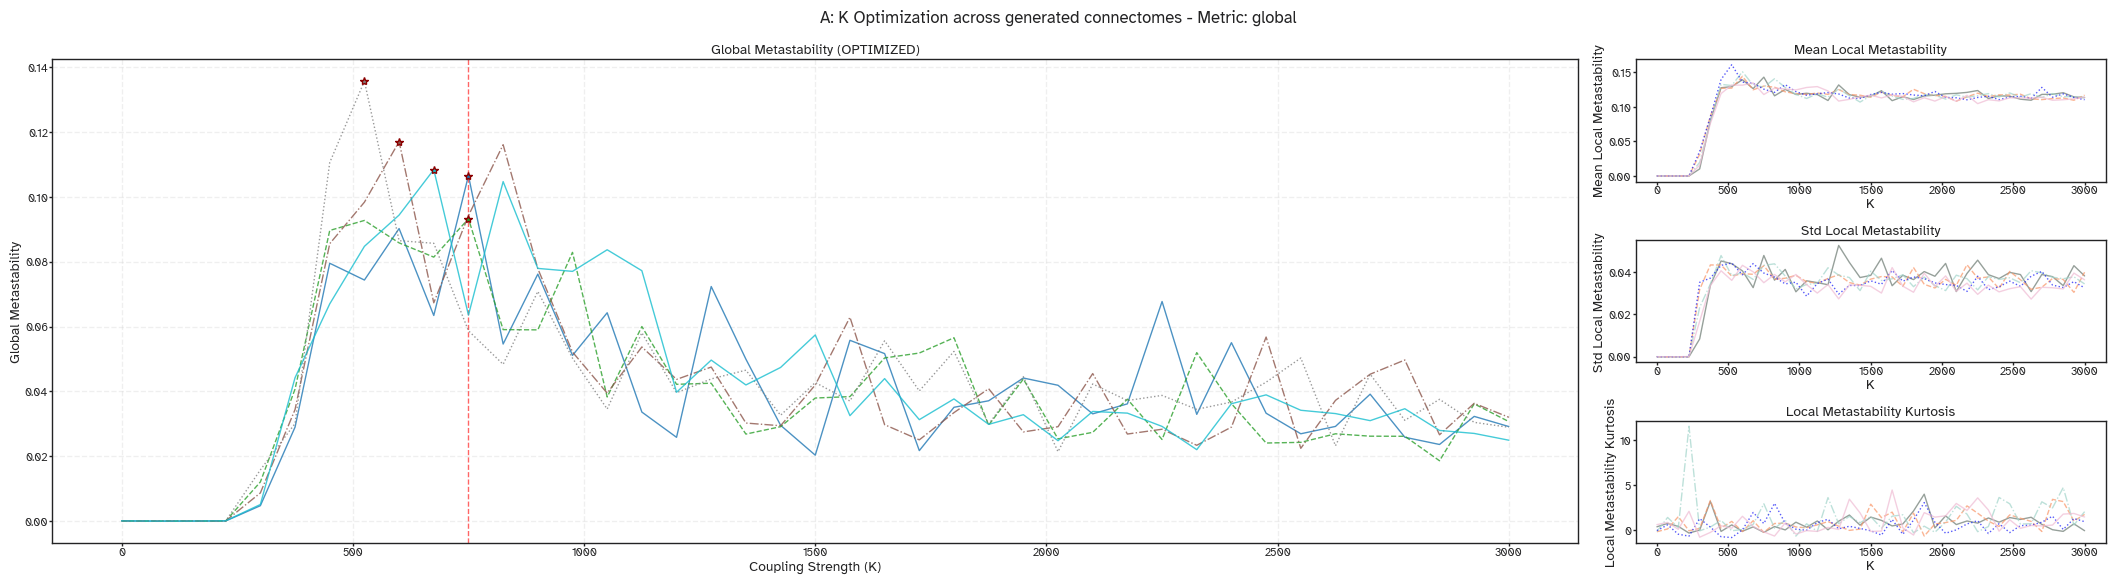

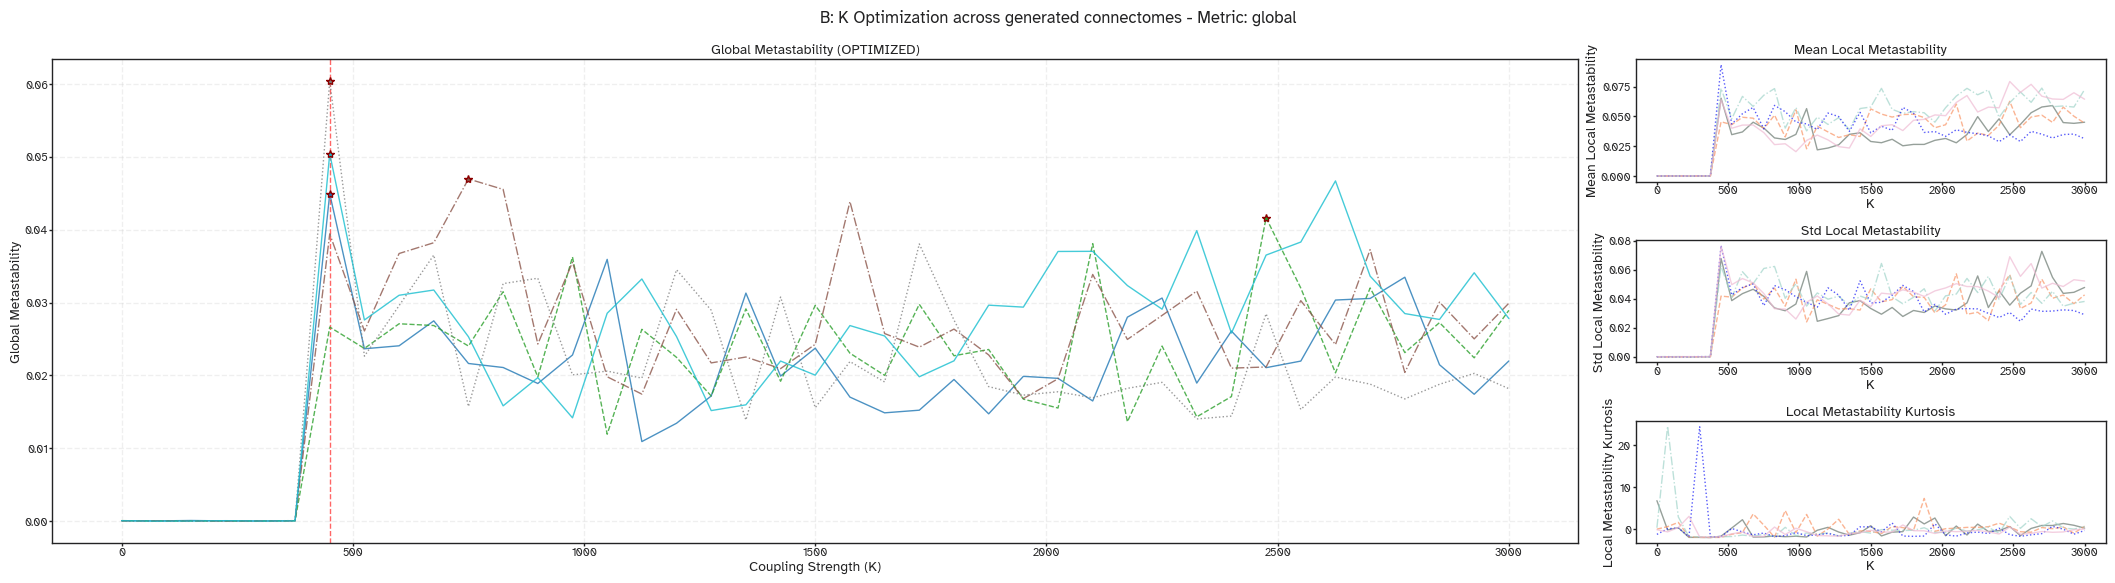

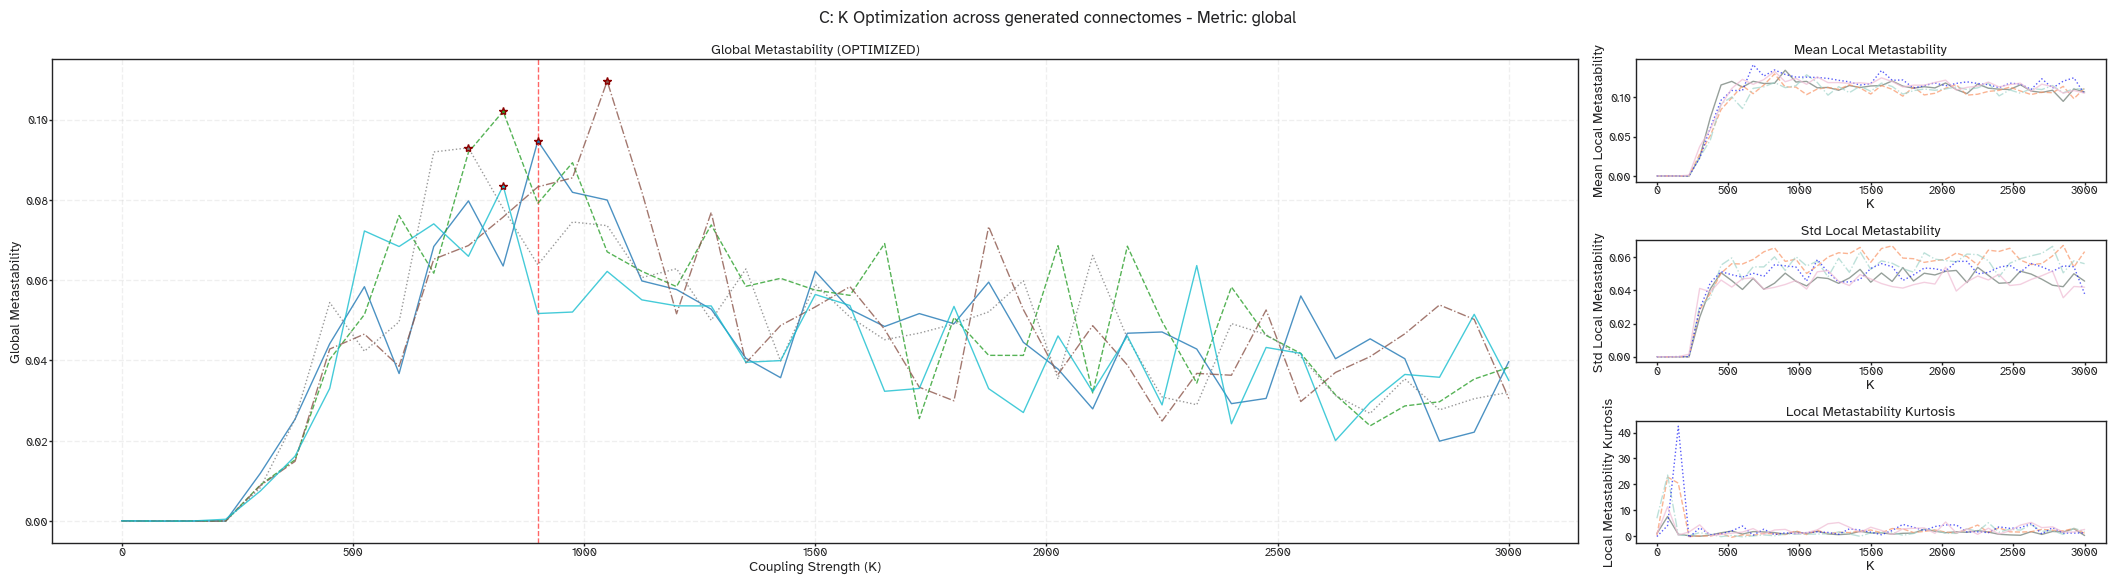

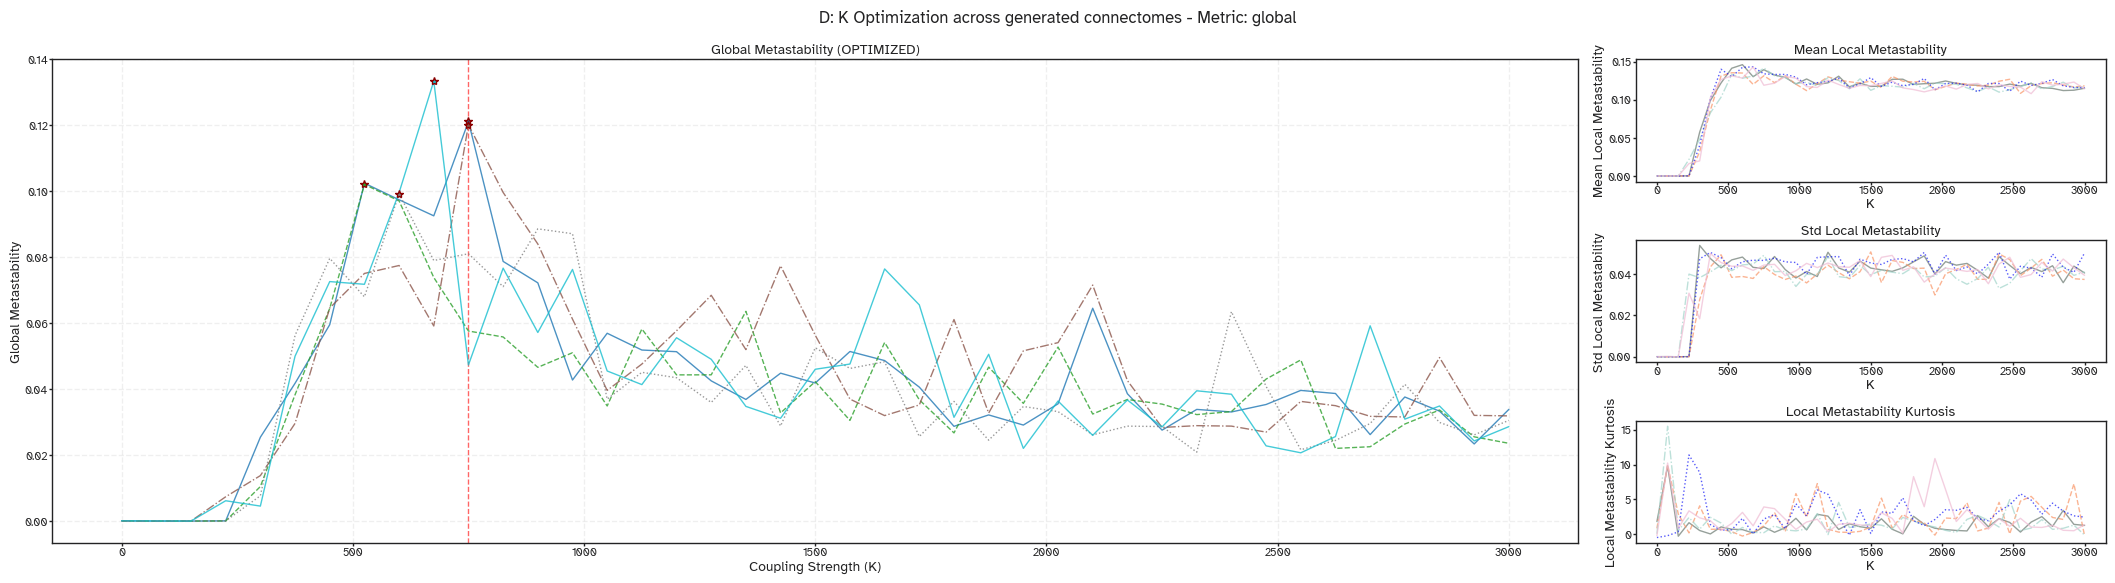

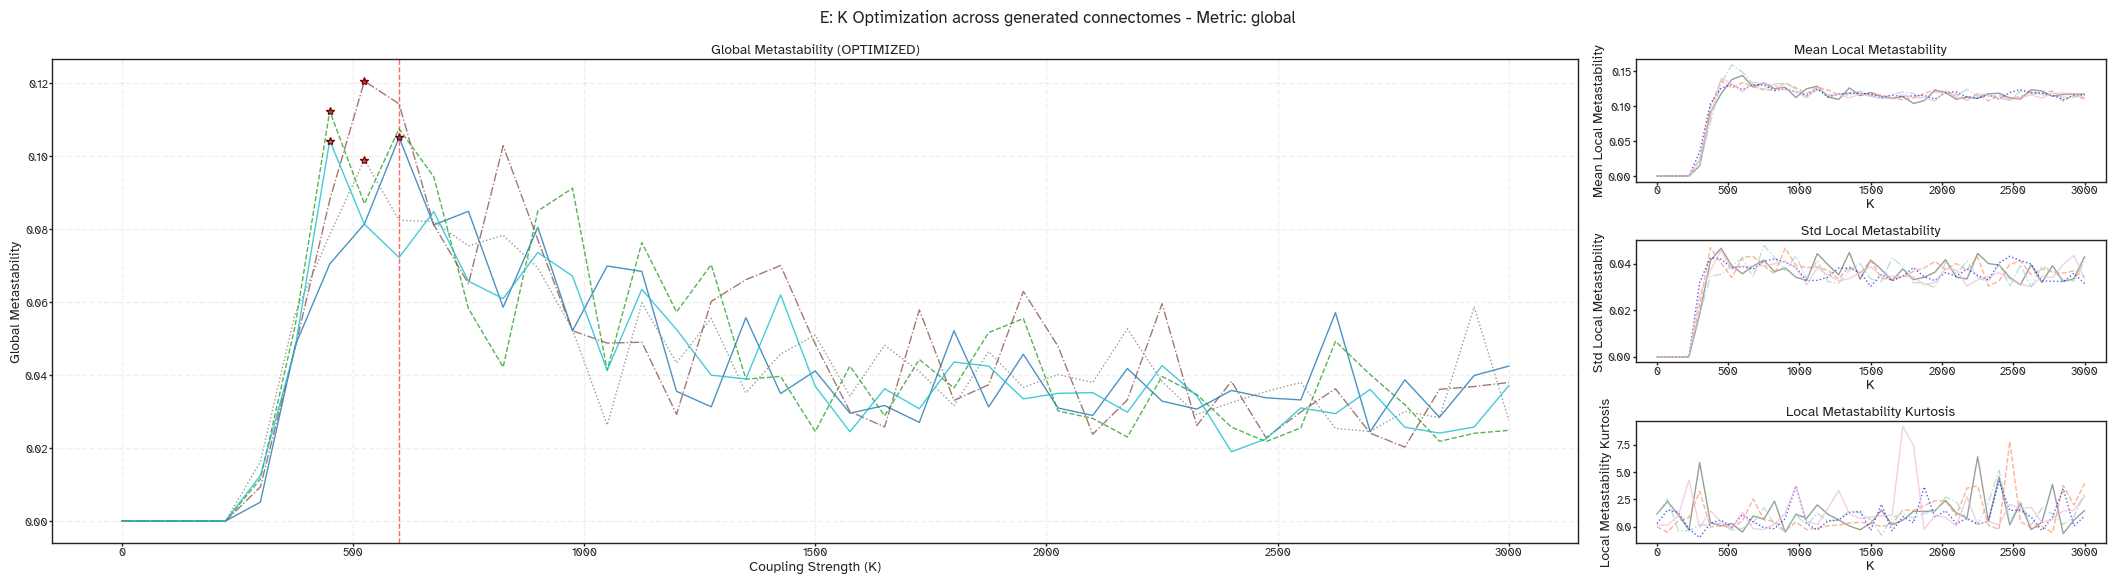

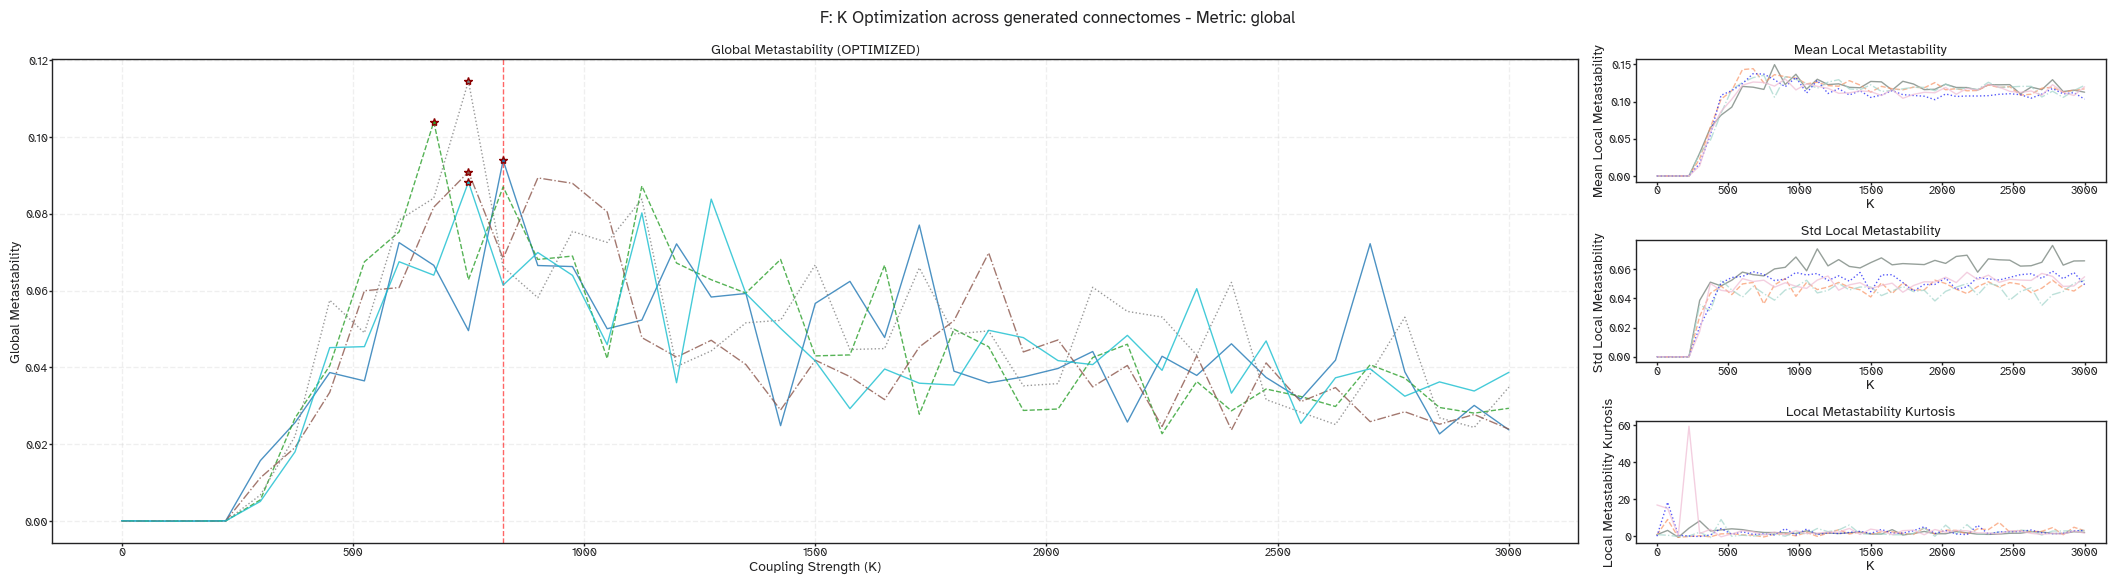

In [ ]:
# total: 54 min for 5 animals (when 200 total nodes)
for id in range(number_connectomes*6): # ids_to_evaluate:
    results_arr = np.load(save_dir / f"results_arr_partial_animal_id_{id}.npy", allow_pickle=True)
    start_idx_arr = np.load(save_dir / f"evaluated_ids_partial_animal_id_{id}.npy", allow_pickle=True)

for id, label in enumerate(["A", "B", "C", "D", "E", "F"]):
    plot_arr_K_optimization( 
        results_arr[5*id:5*id+5],
        np.array(range(5)),
        optimal_metric, 
        title= f"{label}: K Optimization across generated connectomes - Metric: {optimal_metric}",
        save_path=save_dir / f"K_optimization_plots_{name_data}_{label}.pdf")

### Further way of plotting stuff

In [ ]:
# print(save_dir)
# for id in range(5*6): # ids_to_evaluate:
#     results_arr = np.load(save_dir / f"results_arr_partial_animal_id_{id}.npy", allow_pickle=True)
#     start_idx_arr = np.load(save_dir / f"evaluated_ids_partial_animal_id_{id}.npy", allow_pickle=True)

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/testing/metastability_optimize_K/generated_networks_30_01_consensus_bin_density_10_percent_50_finer_window


In [ ]:
from vizman import viz
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pandas as pd

from matplotlib import font_manager
for font in font_manager.findSystemFonts("figures/Atkinson_Typeface/"):
    font_manager.fontManager.addfont(font)

viz.set_visual_style()
default_sizes = viz.load_data_from_json("sizes.json")
default_colors = viz.load_data_from_json("colors.json")
default_cmaps = viz.give_colormaps()

viz.set_visual_style()
default_sizes = viz.load_data_from_json("sizes.json")
default_colors = viz.load_data_from_json("colors.json")
default_cmaps = viz.give_colormaps()

In [ ]:
# default_colors["warms"]["YELLOW"]

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/testing/metastability_optimize_K/generated_networks_30_01_consensus_bin_density_10_percent_50_finer_window/global_metastability_subplots_gen.pdf


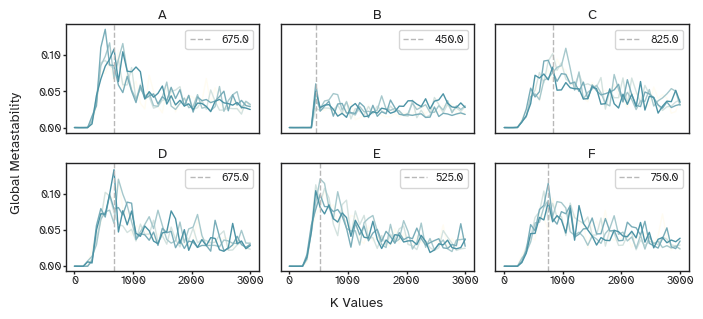

In [ ]:
fig, axs = plt.subplots(2,3,sharex=True, sharey=True, figsize=viz.cm_to_inch((18, 8)))

# Get the bw_db colormap and remove white colors (use only 70% to avoid light colors)
cmap = default_cmaps['bw_db']
colors = [cmap(i) for i in np.linspace(0, 0.7, 5)]

for id, label in enumerate(["A", "B", "C", "D", "E", "F"]):
    axs[id//3, id%3].set_title(label)
    for idx, result in enumerate(results_arr[number_connectomes*id:number_connectomes*id+number_connectomes]):
        axs[id//3, id%3].plot(result["results"]["K_values"], result["results"]["global"], color=colors[idx])

    median_optimal_K = np.median([result["optimal_K"] for result in results_arr[number_connectomes*id:number_connectomes*id+number_connectomes]])
    axs[id//3, id%3].axvline(median_optimal_K, ymin=0, color=default_colors["neutrals"]["GRAY"], linestyle='--', label=median_optimal_K)
    
    # Remove inner ticks
    if id < 3:  # Top row
        axs[id//3, id%3].tick_params(bottom=False)
    if id % 3 != 0:  # Not left column
        axs[id//3, id%3].tick_params(left=False)
    
    axs[id//3, id%3].legend()

# Add single x and y labels
fig.text(0.5, 0.02, 'K Values', ha='center', va='center')
fig.text(0.02, 0.5, 'Global Metastability', ha='center', va='center', rotation='vertical')

plt.tight_layout(rect=[0.03, 0.03, 1, 1])
plt.savefig(save_dir / f"global_metastability_subplots_gen_2.pdf")
print(save_dir / f"global_metastability_subplots_gen_2.pdf")

In [ ]:
fig, axs = plt.subplots(2,3,sharex=True, sharey=True, figsize=viz.cm_to_inch((18, 8)))

# Get the bw_db colormap for individual plots if needed
cmap = default_cmaps['bw_db']

for id, label in enumerate(["A", "B", "C", "D", "E", "F"]):
    axs[id//3, id%3].set_title(label)
    
    # Collect all global values for this group
    group_results = results_arr[number_connectomes*id:number_connectomes*id+number_connectomes]
    K_values = group_results[0]["results"]["K_values"]
    
    # Stack all global metastability curves
    all_globals = np.array([result["results"]["global"] for result in group_results])
    
    # Calculate mean and std/range
    mean_global = np.mean(all_globals, axis=0)
    min_global = np.min(all_globals, axis=0)
    max_global = np.max(all_globals, axis=0)
    
    # Plot fill between min and max
    axs[id//3, id%3].fill_between(K_values, min_global, max_global, 
                                    alpha=0.3, color=default_colors["neutrals"]["GRAY"])
    
    # Plot mean line
    axs[id//3, id%3].plot(K_values, mean_global, 
                          color=default_colors["primary"]["BLUE"], 
                          linewidth=2, label='Mean')
    
    # Add median optimal K
    median_optimal_K = np.median([result["optimal_K"] for result in group_results])
    axs[id//3, id%3].axvline(median_optimal_K, ymin=0, 
                             color=default_colors["neutrals"]["GRAY"], 
                             linestyle='--', 
                             label=f'Median K={median_optimal_K:.1f}')
    
    # Remove inner ticks
    if id < 3:  # Top row
        axs[id//3, id%3].tick_params(bottom=False)
    if id % 3 != 0:  # Not left column
        axs[id//3, id%3].tick_params(left=False)
    
    axs[id//3, id%3].legend()

# Add single x and y labels
fig.text(0.5, 0.02, 'K Values', ha='center', va='center')
fig.text(0.02, 0.5, 'Global Metastability', ha='center', va='center', rotation='vertical')

plt.tight_layout(rect=[0.03, 0.03, 1, 1])
plt.savefig(save_dir / f"global_metastability_subplots_gen_schlauch.pdf")
print(save_dir / f"global_metastability_subplots_gen_schlauch.pdf")